# MLP for Option pricing


### Option price


The European call option is a contract that gives us the right (not the obligation) to buy a stock at a fixed price $K$ (the strike) at time T (maturity). 

At maturity if the market price $S_T > K$ we excerise our right and gain $S_T - K$. If $S_T \leq K$, we don't excersise our right and let the contract expire becauser it’s not worth buying for K.

Thus, the payoff is $\max(S_T-K,0)$.

The Black scholes formula determines a European call option's value at time $t$ as  
\begin{equation*}
C(S,\tau,K,r,\sigma) = S\phi(d_1) - K\exp(-r\tau)\phi(d_2),
\end{equation*}
with 
\begin{equation*}
d_1 = \frac{\log{S/K} + (r + \frac{1}{2}\sigma^2)\tau}{\sigma\sqrt{\tau}} , \quad d_2 = d_1 -\sigma\sqrt{\tau},
\end{equation*}
where $\phi(\cdot)$ is the standard normal CDF. 



## Regression 

Given $n$ observations, predict option prices $\mathbf{Y}\in\mathbb{R}^{n\times 1}$ from input features
$\mathbf{X}\in\mathbb{R}^{n\times 5}$ (stock price, time to maturity etc.)  
\begin{equation*}
    \mathbf{Y} = f(\mathbf{X}) + \mathbf{W},
\end{equation*}
where $f(\cdot)$ maps feature vectors to option prices and $\mathbf{W}\in\mathbb{R}^{n\times 1}$ is the measurement error.


## Supervised Learning 

We want to learn $f$ given a dataset $(\mathbf{X}, \mathbf{Y})$. We do this in a supervised learning setting. 

- We split $(\mathbf{X}, \mathbf{Y})$ into a training set $(\mathbf{X}_{train}, \mathbf{Y}_{train})$ and a test set $(\mathbf{X}_{test}, \mathbf{Y}_{test})$.

- We start with a function (neural network) $f_{\theta}(\cdot)$ that is parameterized by randomly initialized parameters, $\theta \sim N(\mathbf{0}, \mathbf{I})$. Then, for the training features $\mathbf{X}_{train}$, the function $f_{\theta}(\cdot)$ gives us option price predictions $\hat{\mathbf{Y}}$. 

- Next, we check how far the neural network's answers are from the truth:
\begin{equation*}
\mathrm{Error}(\theta) = \|\hat{\mathbf{Y}} -  \mathbf{Y}_{train}\|^2_2 = \|f_{\theta}(\mathbf{X}_{train}) -  \mathbf{Y}_{train}\|^2.
\end{equation*}

Thus, the goal is 
\begin{equation*}
    \theta_{*} = \argmin_{\theta}\, \mathrm{Error}(\theta),
\end{equation*}
which is a non-convex optimization problem. Consequently, taking the derivative and setting it to zero yields a large number of minima, and it is unfeasible to determine which one is the global minimum.


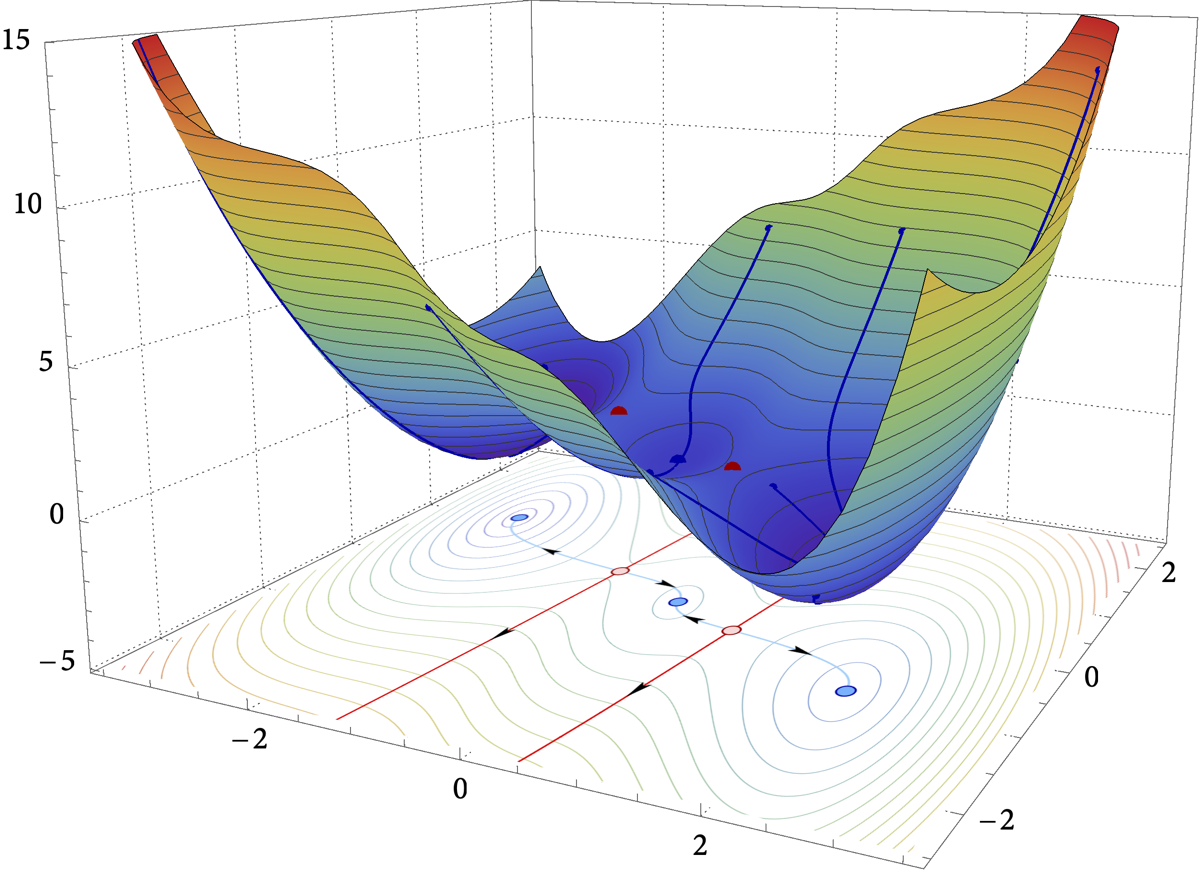

In [ ]:
from IPython.display import Image, display
display(Image(filename="/Users/marwinschmidt/Downloads/ThreeHump3D.png"))

We therefore resort to (stochastic) gradient descent, which walks down this loss landscape:
\begin{equation*}
\theta_{t+1} = \theta_{t} - \eta\nabla_{\theta} \mathrm{Error}(\theta_t),
\end{equation*}
where $\eta$ is the step size and the gradient is computed using backpropagation.

In other words, we tell the neural network how good it is, and this feedback is backpropagated to adjust the parameters such that the new parameters will result in more positive feedback. Eventually, the gradient descent algorithm reaches a minimum and stays there, which is reflected in a converging loss. The associated $\theta_T$ defines $f_{\theta_T}(\cdot)$, which is our best attempt at finding $f$ given the training dataset.

Last, we use the found $f_{\theta_T}$ to compute the error on unseen points, i.e., the test error:
\begin{equation*}
\mathrm{Error}_{test} = \|f_{\theta_T}(\mathbf{X}_{test}) - \mathbf{Y}_{test} \|^2,
\end{equation*}
which is a proxy for the generalization error.

This is because
\begin{equation*}
    \mathrm{Error}_{test} - \mathrm{Error}(\theta) \approx \frac{1}{m} \sum_{i=1}^{m} (f(x_i) - f_{\theta}(x_i))^2 = \frac{1}{m} \sum_{i=1}^{m} (\underbrace{f(x_i) - f_{*}(x_i)}_{\text{Bias}} + \underbrace{f_{*}(x_i)  - f_{\theta}(x_i)}_{\text{Variance}})^2, 
\end{equation*}
where the sum goes over all test points. Recall that  $f(\cdot)$ is the true function, $f_{\theta}(\cdot)$ is the prediction, and $f_{*}(\cdot)$ is the closest function to $f$ that our MLP can find.


## Implementation


In [218]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.optim as optim

In [219]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


### Dataset $\mathrm(X,Y)$


In [220]:
# Define the Black-Scholes formula (this is f)
def black_scholes_call(S, K, T, r, sigma):
    """
    Computes the European call option price using the Black-Scholes formula.
    
    Parameters:
        S (float): Stock price (underlying)
        K (float): Strike price
        T (float): Time to maturity
        r (float): Risk-free interest rate
        sigma (float): Volatility of the stock
    
    Returns:
        float: Price for the call option
    """
    # Calculate d1 and d2 using the Black-Scholes formula components
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    # Compute the call option price
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

In [221]:
# Generate a synthetic dataset using Black-Scholes
def generate_dataset(n_samples, noise_std=0.2):
    """
    Generate synthetic data for option pricing.

    Features: [S, K, T, r, sigma]
    Label: Call option price computed from the Black-Scholes formula,
           with additive Gaussian noise.
    """
    # Randomly generate parameters within realistic ranges.
    S = np.random.uniform(50, 150, n_samples)      # Underlying asset prices
    K = np.random.uniform(50, 150, n_samples)      # Strike prices
    T = np.random.uniform(0.1, 2, n_samples)       # Time to maturity (in years)
    r = np.random.uniform(0.01, 0.05, n_samples)   # Interest rates
    sigma = np.random.uniform(0.1, 0.5, n_samples) # Volatility values

    # Compute noiseless Black-Scholes call prices.
    call_prices = black_scholes_call(S, K, T, r, sigma)

    # Add Gaussian noise to the target and keep prices non-negative.
    noise = np.random.normal(loc=0.0, scale=noise_std, size=n_samples)
    noisy_call_prices = np.clip(call_prices + noise
                                , a_min=0.0, a_max=None)

    # Stack features together (each row corresponds to one sample).
    X = np.stack([S, K, T, r, sigma], axis=1)  # Feature matrix of shape (n_samples, 5).
    y = noisy_call_prices.reshape(-1, 1)       # Column vector of noisy option prices.
    return X, y

In [230]:
dataset_size = 10**4
(X, y) = generate_dataset(dataset_size, noise_std=10)#10

### Data pipeline 


In [231]:
# Shuffle feature vectors and labels, then split the dataset into training (80%) and testing (20%) sets.

train_size = int(0.8 * dataset_size)

rng = np.random.default_rng(42) 
perm = rng.permutation(dataset_size) # Shuffle all row indices randomly; e.g., if dataset_size = 8, perm could be [3, 0, 6, 1, 7, 4, 2, 5].

train_idx = perm[:train_size]
test_idx = perm[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [232]:
# Normalize to prevent vanishing and exploding gradients.

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler() 

X_train = x_scaler.fit_transform(X_train) # Map values to [0, 1] using x' = (x - x_min) / (x_max - x_min).
X_test  = x_scaler.transform(X_test) # Use min/max values learned from X_train to scale X_test.

y_train = y_scaler.fit_transform(y_train)
y_test  = y_scaler.transform(y_test)


### Architecture 


In [239]:
class MLP(nn.Module): # Inherit from nn.Module to use model.parameters(), model.to(device), and train/eval modes.

    def __init__(self, input_dim):
        """
        A simple multi-layer perceptron with one hidden layer structure.
        """
        super(MLP, self).__init__() # Since we use inheritance, initialize the parent class nn.Module.
        self.model = nn.Sequential(
            nn.Linear(input_dim, 100),  # Input layer to first hidden layer
            nn.ReLU(),                  # Activation function
            nn.Linear(100, 60),         # Second hidden layer
            nn.ReLU(),                  # Activation function
            nn.Linear(60, 1)            # Output layer (predicts option price)
        )

    def forward(self, x): # Define how inputs flow through the model; when calling y = mlp(x), PyTorch internally calls forward(x), and here it delegates to nn.Sequential.
        return self.model(x) # y = W_3 ReLU(W_2 ReLU(W_1 x + b_1) + b_2) + b_3


### Training


In [257]:
# Define a training function to find the optimal parameters (W*, b*) for the training dataset.
def train_model(model, X_train, y_train, n_epochs=500, learning_rate=1e-3, loss_fn=nn.MSELoss(), delta = 1e-7):
    """
    Train the given PyTorch model on training data.
    
    Parameters:
        model: PyTorch model to train
        X_train: Input features (numpy array)
        y_train: Target values (numpy array)
        n_epochs: Number of training epochs, i.e., how many times the model sees the full training dataset
        learning_rate: Learning rate for the optimizer
        loss_fn: Loss function (e.g., MSELoss)
    """
    # Convert numpy arrays to torch tensors
    X_train_tensor = torch.from_numpy(X_train).float() 
    y_train_tensor = torch.from_numpy(y_train).float()
    
    loss_history = []

    # Use Adam optimizer: SGD with momentum plus per-parameter adaptive step sizes
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # model.parameters() gives Adam access to all trainable weights and biases.
    
    # Training loop
    for epoch in range(n_epochs): # One full update cycle over the entire dataset.
        model.train()  # Set the model to training mode
        optimizer.zero_grad()  # Clear old gradients because PyTorch accumulates gradients by default
        
        # Forward pass
        predictions = model(X_train_tensor) # Compute the network output y = W_3 ReLU(W_2 ReLU(W_1 x + b_1) + b_2) + b_3.
        # Compute loss
        mse_loss = loss_fn(predictions, y_train_tensor)
        # Regularization
        l1 = sum(param.abs().sum() for name, param in model.named_parameters() if "weight" in name) # L1 tends to encourage sparsity (many weights pushed toward 0), which can reduce overfitting
        total_loss = mse_loss + delta*l1 # Assess how close the output is to the ground truth.

        # Backward pass
        total_loss.backward() # Computes gradients of total_loss w.r.t. every parameter, using autograd (backpropagation).
        
        optimizer.step() # Adam updates parameters using the gradients computed above.
        loss_history.append(total_loss.item())

        # Print the loss every 10 epochs for monitoring
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {total_loss.item():.6f}")
    
    model.training_loss_history = loss_history
    return model


Training Simple MLP Model:
Epoch 10/500, Loss: 0.030203
Epoch 20/500, Loss: 0.016392
Epoch 30/500, Loss: 0.010881
Epoch 40/500, Loss: 0.009376
Epoch 50/500, Loss: 0.008031
Epoch 60/500, Loss: 0.006933
Epoch 70/500, Loss: 0.006323
Epoch 80/500, Loss: 0.005930
Epoch 90/500, Loss: 0.005704
Epoch 100/500, Loss: 0.005585
Epoch 110/500, Loss: 0.005516
Epoch 120/500, Loss: 0.005471
Epoch 130/500, Loss: 0.005438
Epoch 140/500, Loss: 0.005411
Epoch 150/500, Loss: 0.005387
Epoch 160/500, Loss: 0.005368
Epoch 170/500, Loss: 0.005354
Epoch 180/500, Loss: 0.005342
Epoch 190/500, Loss: 0.005331
Epoch 200/500, Loss: 0.005322
Epoch 210/500, Loss: 0.005314
Epoch 220/500, Loss: 0.005307
Epoch 230/500, Loss: 0.005301
Epoch 240/500, Loss: 0.005295
Epoch 250/500, Loss: 0.005289
Epoch 260/500, Loss: 0.005284
Epoch 270/500, Loss: 0.005278
Epoch 280/500, Loss: 0.005272
Epoch 290/500, Loss: 0.005267
Epoch 300/500, Loss: 0.005261
Epoch 310/500, Loss: 0.005256
Epoch 320/500, Loss: 0.005251
Epoch 330/500, Loss: 0

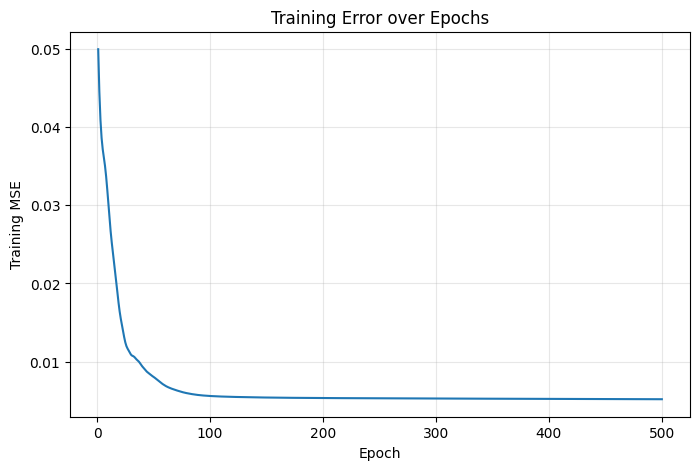

In [279]:
print("Training Simple MLP Model:")
model_simple = MLP(input_dim=X.shape[1]) # We try to find the optimal weights and biases (W*, b*), then create a prediction: y = W_3 ReLU(W_2 ReLU(W_1 x + b_1) + b_2) + b_3.
model_simple = train_model(model_simple, X_train, y_train, n_epochs=500, learning_rate=1e-3, loss_fn=nn.MSELoss(), delta = 0.0) # Train the model so it learns these optimal weights and biases.

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(model_simple.training_loss_history) + 1), model_simple.training_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Training MSE")
plt.title("Training Error over Epochs")
plt.grid(alpha=0.3)
plt.show()


### Testing


In [282]:
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

model_simple.eval() # Evaluation mode (e.g., dropout is turned off).
with torch.no_grad():
    predictions_simple = model_simple(X_test_tensor) # With parameters learned during training (W*, b*), generate output y = W*_3 ReLU(W*_2 ReLU(W*_1 x + b*_1) + b*_2) + b*_3 for unseen feature vectors.
    test_error = nn.MSELoss()(predictions_simple, y_test_tensor) # Check how far each prediction on unseen feature vectors is from the ground truth.
    # print(test_error)


### Results


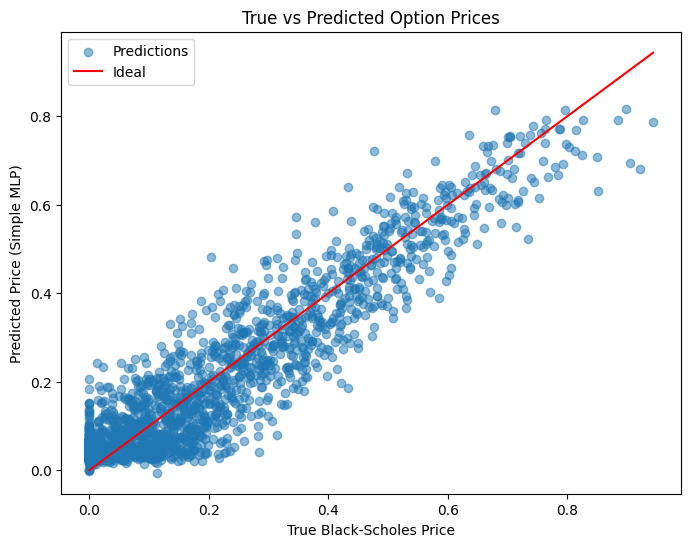

In [283]:
# Plot: True vs Predicted Option Prices for the Simple MLP

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions_simple.numpy(), alpha=0.5, label="Predictions")
plt.xlabel("True Black-Scholes Price")
plt.ylabel("Predicted Price (Simple MLP)")
plt.title("True vs Predicted Option Prices")
# Plot a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label="Ideal")
plt.legend()
plt.show()

## Hyperparameter search and cross-validation 


### Benefits of cross-validation: 
- more reliable estimate of how well a model will generalize
- not relying on a lucky train/val/test split
- if fold scores vary a lot, it’s a sign the model is sensitive to the training data (potentially unstable/overfitting)

In [291]:
import random
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
! pip install optuna
import optuna
from optuna.samplers import TPESampler


def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def generate_dataset(n_samples: int = 10_000, noise_std: float = 0.2):
    S = np.random.uniform(50, 150, n_samples)
    K = np.random.uniform(50, 150, n_samples)
    T = np.random.uniform(0.1, 2.0, n_samples)
    r = np.random.uniform(0.01, 0.05, n_samples)
    sigma = np.random.uniform(0.1, 0.5, n_samples)

    y_clean = black_scholes_call(S, K, T, r, sigma)
    noise = np.random.normal(loc=0.0, scale=noise_std, size=n_samples)
    y_noisy = np.clip(y_clean + noise
                      , a_min=0.0, a_max=None).reshape(-1, 1)

    X = np.stack([S, K, T, r, sigma], axis=1)
    return X.astype(np.float32), y_noisy.astype(np.float32)

### Flexible neural network architecture


In [292]:
def get_activation(name: str) -> nn.Module:
    if name == "relu":
        return nn.ReLU()
    if name == "tanh":
        return nn.Tanh()
    if name == "gelu":
        return nn.GELU()
    if name == "elu":
        return nn.ELU()
    if name == "leaky_relu":
        return nn.LeakyReLU(0.1)
    raise ValueError(f"Unsupported activation: {name}")


class FlexibleMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims, activation: str):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(get_activation(activation))
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

### Training with early-stopping


In [293]:
def build_optimizer(name: str, params, lr: float, weight_decay: float):
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if name == "rmsprop":
        return torch.optim.RMSprop(params, lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Unsupported optimizer: {name}")


def train_with_early_stopping(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer,
    device: torch.device,
    max_epochs: int,
    patience: int,
    l1_lambda: float,
):
    criterion = nn.MSELoss()
    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        n_train = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            mse_loss = criterion(pred, yb)

            if l1_lambda > 0.0:
                l1_penalty = sum(
                    p.abs().sum() for n, p in model.named_parameters() if "weight" in n
                )
                loss = mse_loss + l1_lambda * l1_penalty
            else:
                loss = mse_loss

            loss.backward()
            optimizer.step()
            # We are working with mini-batch gradient descent
            batch_size = xb.size(0)
            running_loss += mse_loss.item() * batch_size
            n_train += batch_size

        train_epoch_loss = running_loss / max(n_train, 1)
        train_losses.append(train_epoch_loss)

        
        model.eval()
        val_running = 0.0
        n_val = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                pred = model(xb)
                val_loss = criterion(pred, yb)
                batch_size = xb.size(0)
                val_running += val_loss.item() * batch_size
                n_val += batch_size

        val_epoch_loss = val_running / max(n_val, 1)
        val_losses.append(val_epoch_loss)

        # For early stopping
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_loss, best_epoch, train_losses, val_losses

### Grid search for hyperparameters


In [294]:
# Here we create an ensemble of hyperparameter configurations.
def suggest_hyperparams(trial):
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_dims = [
        trial.suggest_int(f"n_units_l{i}", 32, 512, log=True) for i in range(n_layers)
    ]

    return {
        "n_layers": n_layers,
        "hidden_dims": hidden_dims,
        "activation": trial.suggest_categorical(
            "activation", ["relu", "tanh", "gelu", "elu", "leaky_relu"]
        ),
        "optimizer": trial.suggest_categorical("optimizer", ["adam", "adamw", "rmsprop"]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        "max_epochs": trial.suggest_int("max_epochs", 80, 300),
        "patience": trial.suggest_int("patience", 10, 40),
        "l1_lambda": trial.suggest_float("l1_lambda", 1e-9, 1e-4, log=True),
    }


def objective(trial, X_train, y_train, device, n_splits=5, seed=42):
    hp = suggest_hyperparams(trial) # Here we consider one hyperparameter configuration sampled by suggest_hyperparams().
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed) # Partition the training set into 5 disjoint folds
    fold_losses = []

    ##################################################
    # KFold(n_splits=5) splits X_train into 5 non-overlapping folds.
    # It runs for 5 rounds. In round i, val_idx points to fold i (validation), and train_idx points to the other 4 folds (training).
    # In one Optuna trial, we train 5 separate models and average their validation losses to score the trial.
    ##################################################
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train), start=1): # val_idx and train_idx are validation/training indices; fold_idx counts folds starting at 1.
        X_tr_raw, X_val_raw = X_train[train_idx], X_train[val_idx]
        y_tr_raw, y_val_raw = y_train[train_idx], y_train[val_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_tr = x_scaler.fit_transform(X_tr_raw).astype(np.float32)
        X_val = x_scaler.transform(X_val_raw).astype(np.float32)
        y_tr = y_scaler.fit_transform(y_tr_raw).astype(np.float32)
        y_val = y_scaler.transform(y_val_raw).astype(np.float32)

        train_ds = TensorDataset(
            torch.from_numpy(X_tr),
            torch.from_numpy(y_tr),
        )
        val_ds = TensorDataset(
            torch.from_numpy(X_val),
            torch.from_numpy(y_val),
        )

        train_loader = DataLoader(
            train_ds, batch_size=hp["batch_size"], shuffle=True, drop_last=False
        )
        val_loader = DataLoader(
            val_ds, batch_size=hp["batch_size"], shuffle=False, drop_last=False
        )
        # Inside each fold we train a brand-new model with early stopping
        model = FlexibleMLP(
            input_dim=X_train.shape[1],
            hidden_dims=hp["hidden_dims"],
            activation=hp["activation"],
        ).to(device)

        optimizer = build_optimizer(
            hp["optimizer"], model.parameters(), hp["lr"], hp["weight_decay"]
        )
        
        # Stop training when validation loss stops improving, and keep the best model weights seen so far.
        # Prevent the scenario where training loss keeps dropping while validation loss stagnates or worsens, i.e., avoid fitting noise.
        best_val_loss, _, _, _ = train_with_early_stopping(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            device=device,
            max_epochs=hp["max_epochs"],
            patience=hp["patience"],
            l1_lambda=hp["l1_lambda"],
        )

        fold_losses.append(best_val_loss)
    # Trial score = mean validation loss across folds, which Optuna will try to minimize.
    return float(np.mean(fold_losses))


### Main


In [295]:
seed = 42
device = torch.device("mps")

# Generate dataset
X, y = generate_dataset(n_samples=10000, noise_std=0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, shuffle=True
)

# Find optimal hyperparameters using X_train and y_train.
n_trials = 2
print(f"Starting Optuna search with {n_trials} trials (5-fold CV)...")

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=seed), # Smarter search algorithm than random.
)

study.optimize(
    lambda trial: objective(trial, X_train, y_train, device, n_splits=5, seed=seed),
    n_trials=n_trials,
    show_progress_bar=True,
)

best_trial_params = study.best_trial.params
n_layers = best_trial_params["n_layers"]
best_params = {
    "n_layers": n_layers,
    "hidden_dims": [best_trial_params[f"n_units_l{i}"] for i in range(n_layers)],
    "activation": best_trial_params["activation"],
    "optimizer": best_trial_params["optimizer"],
    "lr": best_trial_params["lr"],
    "weight_decay": best_trial_params["weight_decay"],
    "batch_size": best_trial_params["batch_size"],
    "max_epochs": best_trial_params["max_epochs"],
    "patience": best_trial_params["patience"],
    "l1_lambda": best_trial_params["l1_lambda"],
}

print("\nBest CV MSE (scaled target space):", study.best_value)
print("Best params:")
for k, v in study.best_trial.params.items():
    print(f"  {k}: {v}")


[I 2026-03-04 17:30:00,963] A new study created in memory with name: no-name-46f9e8ef-1c1f-4d5a-9de0-3b6628451473


Starting Optuna search with 2 trials (5-fold CV)...


Best trial: 0. Best value: 0.000230337:  50%|█████     | 1/2 [00:37<00:37, 37.23s/it]

[I 2026-03-04 17:30:38,192] Trial 0 finished with value: 0.00023033731640316547 and parameters: {'n_layers': 2, 'n_units_l0': 447, 'n_units_l1': 243, 'activation': 'leaky_relu', 'optimizer': 'adamw', 'lr': 0.04147225000481639, 'weight_decay': 0.0009877700294007917, 'batch_size': 512, 'max_epochs': 195, 'patience': 23, 'l1_lambda': 2.8585493941961944e-08}. Best is trial 0 with value: 0.00023033731640316547.


Best trial: 1. Best value: 0.000165264: 100%|██████████| 2/2 [05:03<00:00, 151.60s/it]

[I 2026-03-04 17:35:04,154] Trial 1 finished with value: 0.00016526415018597619 and parameters: {'n_layers': 3, 'n_units_l0': 46, 'n_units_l1': 71, 'n_units_l2': 88, 'activation': 'tanh', 'optimizer': 'adamw', 'lr': 0.00014982086432155476, 'weight_decay': 0.0049352962094021124, 'batch_size': 64, 'max_epochs': 231, 'patience': 23, 'l1_lambda': 4.075596440072872e-09}. Best is trial 1 with value: 0.00016526415018597619.

Best CV MSE (scaled target space): 0.00016526415018597619
Best params:
  n_layers: 3
  n_units_l0: 46
  n_units_l1: 71
  n_units_l2: 88
  activation: tanh
  optimizer: adamw
  lr: 0.00014982086432155476
  weight_decay: 0.0049352962094021124
  batch_size: 64
  max_epochs: 231
  patience: 23
  l1_lambda: 4.075596440072872e-09


In [296]:
# With the optimal hyperparameters, train and then test on unseen data.

# Build DataLoaders (training and validation) for early stopping using X_train and y_train.
X_tr_raw, X_val_raw, y_tr_raw, y_val_raw = train_test_split(
    X_train, y_train, test_size=0.1, random_state=seed, shuffle=True
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_tr = x_scaler.fit_transform(X_tr_raw).astype(np.float32)
X_val = x_scaler.transform(X_val_raw).astype(np.float32)
y_tr = y_scaler.fit_transform(y_tr_raw).astype(np.float32)
y_val = y_scaler.transform(y_val_raw).astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"], shuffle=False)

# Build model architecture with optimal hyperparameters.
model = FlexibleMLP(
    input_dim=X_train.shape[1],
    hidden_dims=best_params["hidden_dims"],
    activation=best_params["activation"],
).to(device)

optimizer = build_optimizer(
    best_params["optimizer"],
    model.parameters(),
    best_params["lr"],
    best_params["weight_decay"],
)

# Train
_, best_epoch, train_loss_history, _ = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    max_epochs=best_params["max_epochs"],
    patience=best_params["patience"],
    l1_lambda=best_params["l1_lambda"],
)


Test metrics:
  mse: 0.085102
  rmse: 0.291723
  mae: 0.224610
  r2: 0.999834


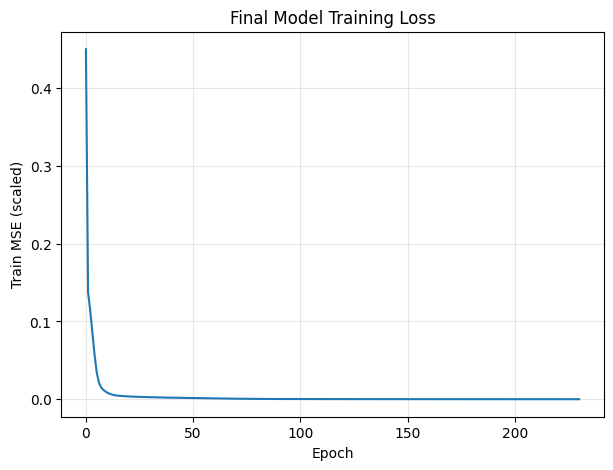

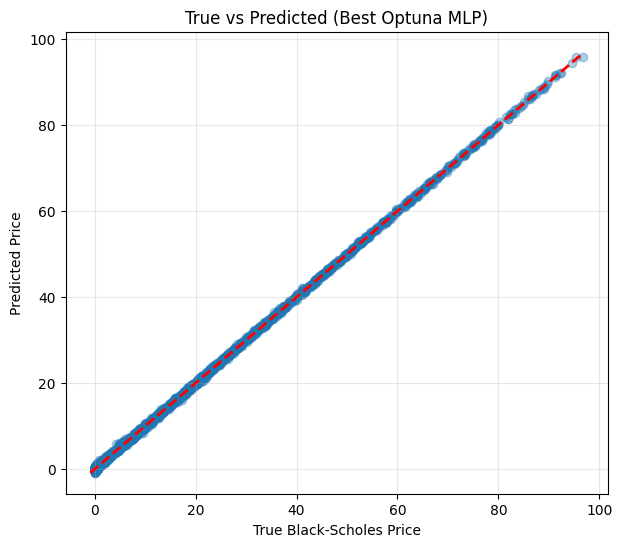

In [297]:
# Test
# Evaluate the final model using the unseen test dataset.
def evaluate(model, x_scaler, y_scaler, X_test, y_test, device):
    X_test_scaled = x_scaler.transform(X_test).astype(np.float32)
    X_test_tensor = torch.from_numpy(X_test_scaled).to(device)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_test_tensor).cpu().numpy()

    y_pred = y_scaler.inverse_transform(pred_scaled)

    metrics = {
        "mse": mean_squared_error(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    }
    return metrics, y_pred



metrics, y_pred = evaluate(model, x_scaler, y_scaler, X_test, y_test, device)
print("\nTest metrics:")
for name, value in metrics.items():
    print(f"  {name}: {value:.6f}")

plt.figure(figsize=(7, 5))
plt.plot(train_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Train MSE (scaled)")
plt.title("Final Model Training Loss")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.35)
min_y = min(y_test.min(), y_pred.min())
max_y = max(y_test.max(), y_pred.max())
plt.plot([min_y, max_y], [min_y, max_y], "r--", linewidth=2)
plt.xlabel("True Black-Scholes Price")
plt.ylabel("Predicted Price")
plt.title("True vs Predicted (Best Optuna MLP)")
plt.grid(alpha=0.3)
plt.show()

# European put option 

The European put option give you the right (not the obligation) to sell the underlying at $K$ at time $T$.
\begin{equation}
P(S,K,T,r,\sigma)=K e^{-rT}\,\Phi(-d_2)\;-\;S\,\Phi(-d_1),
\end{equation}
with 
\begin{equation}
d_1=\frac{\ln(S/K)+\left(r+\tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T},
\end{equation}
where $\Phi(\cdot)$ is the standard normal CDF.